**FINANCIAL MODELLING**

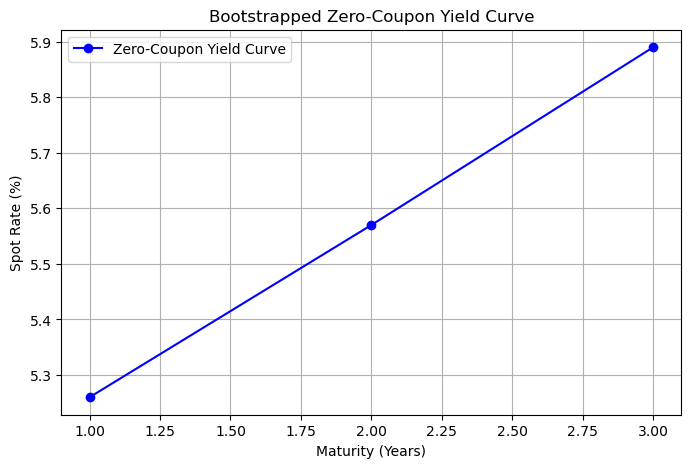

In [2]:
import numpy as np
import matplotlib.pyplot as mt

# Given time to maturity (years)
maturities = np.array([1, 2, 3])

# Derived spot rates (%)
spot_rates = np.array([5.26, 5.57, 5.89])

# Plot yield curve
mt.figure(figsize=(8, 5))
mt.plot(maturities, spot_rates, marker='o', linestyle='-', color='b', label="Zero-Coupon Yield Curve")
mt.xlabel("Maturity (Years)")
mt.ylabel("Spot Rate (%)")
mt.title("Bootstrapped Zero-Coupon Yield Curve")
mt.legend()
mt.grid(True)

# Show plot
mt.show()


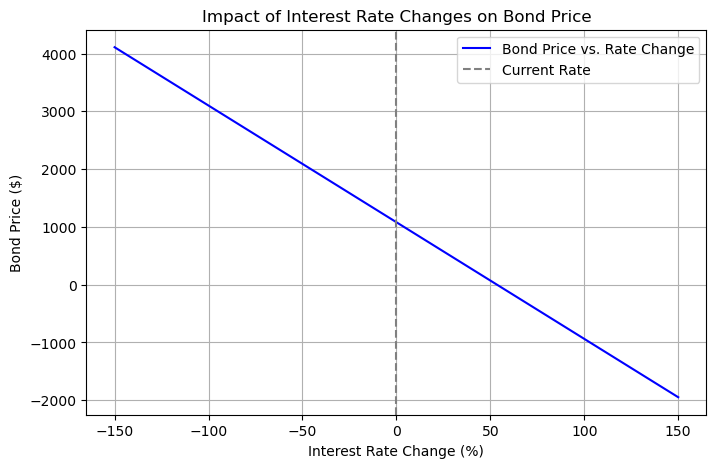

Bond Price: $1081.11
Macaulay Duration: 1.94 years
Modified Duration: 1.87 years


In [3]:


# Given bond parameters
face_value = 1000  # Bond principal
coupon_rate = 0.05  # 5% annual coupon
years = 10  # Bond maturity
market_rate = 0.04  # 4% current market interest rate

# Calculate bond price
coupon_payment = face_value * coupon_rate
discount_factors = [(1 + market_rate) ** -(i+1) for i in range(years)]
bond_price = sum(coupon_payment * d for d in discount_factors) + face_value * discount_factors[-1]

# Calculate Macaulay Duration
weighted_cash_flows = [(i+1) * coupon_payment * discount_factors[i] for i in range(years)]
macaulay_duration = sum(weighted_cash_flows) / bond_price

# Calculate Modified Duration
modified_duration = macaulay_duration / (1 + market_rate)

# Simulate price changes for different interest rates
rate_changes = np.linspace(-1.5, 1.5, 100)  # Interest rate shifts (-1.5% to +1.5%)
new_prices = bond_price * (1 - rate_changes * modified_duration)

# Plot results
mt.figure(figsize=(8, 5))
mt.plot(rate_changes * 100, new_prices, label="Bond Price vs. Rate Change", color="blue")
mt.axvline(0, linestyle="--", color="gray", label="Current Rate")
mt.xlabel("Interest Rate Change (%)")
mt.ylabel("Bond Price ($)")
mt.title("Impact of Interest Rate Changes on Bond Price")
mt.legend()
mt.grid(True)
mt.show()

# Print results
print(f"Bond Price: ${bond_price:.2f}")
print(f"Macaulay Duration: {macaulay_duration:.2f} years")
print(f"Modified Duration: {modified_duration:.2f} years")


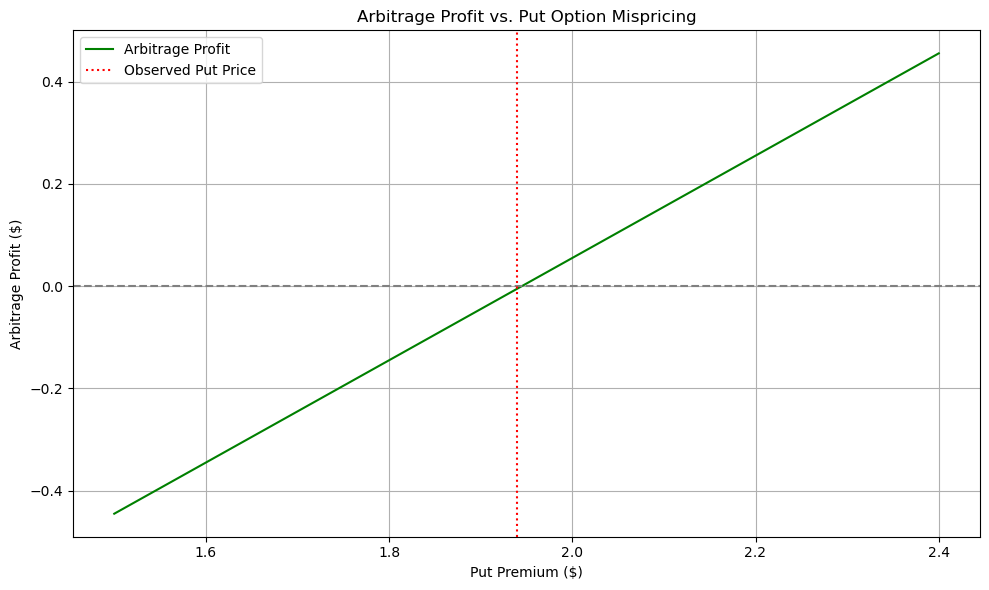

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Known values
K = 35              # Strike price
r = 0.043           # Annual interest rate
T = 1/12            # Time to maturity in years
C = 0.23            # Call premium
S0 = 33.16          # Spot price
pv_K = K * np.exp(-r * T)  # Present value of strike price

# Simulate a range of put prices around fair value
put_prices = np.linspace(1.50, 2.40, 100)  # Simulated put premiums
lhs = C + pv_K
rhs = put_prices + S0
profit = rhs - lhs  # Arbitrage profit from overpriced put

# Plot it!
plt.figure(figsize=(10,6))
plt.plot(put_prices, profit, label="Arbitrage Profit", color='green')
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(1.94, color='red', linestyle=':', label='Observed Put Price')
plt.title("Arbitrage Profit vs. Put Option Mispricing")
plt.xlabel("Put Premium ($)")
plt.ylabel("Arbitrage Profit ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [1]:
import numpy as np

# --- Liability ---
liability_amount = 1000
liability_year = 5
liability_rate = 0.05  # discount rate
PV_liability = liability_amount / (1 + liability_rate) ** liability_year
D_liability = liability_year  # since it's a single cash flow

# --- Define two bonds (bullet bonds: no coupons for simplicity) ---
# Bond A: 2-year maturity
# Bond B: 8-year maturity
bond_A_year = 2
bond_B_year = 8

# Calculate present values
PV_A = lambda w: w * PV_liability / (1 + liability_rate) ** bond_A_year
PV_B = lambda w: (1 - w) * PV_liability / (1 + liability_rate) ** bond_B_year

# Calculate durations (as weighted average of cash flow times)
D_portfolio = lambda w: (PV_A(w) * bond_A_year + PV_B(w) * bond_B_year) / (PV_A(w) + PV_B(w))

# --- Find allocation w that matches duration ---
weights = np.linspace(0, 1, 101)
matches = [(w, D_portfolio(w)) for w in weights if abs(D_portfolio(w) - D_liability) < 0.05]

# Display result
if matches:
    w_star, D_match = matches[0]
    print(f"✅ Match found with weight {w_star:.2f} in Bond A and {1 - w_star:.2f} in Bond B")
    print(f"→ Portfolio Duration: {D_match:.2f}, Target Duration: {D_liability}")
    print(f"→ Portfolio PV: ${PV_A(w_star) + PV_B(w_star):,.2f}, Target PV: ${PV_liability:,.2f}")
else:
    print("❌ No duration match found in search range.")


✅ Match found with weight 0.42 in Bond A and 0.58 in Bond B
→ Portfolio Duration: 5.05, Target Duration: 5
→ Portfolio PV: $606.07, Target PV: $783.53
